# ML-03 — Frame Your Lane as an ML Task

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w02_ml_task_framing.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Import Requires libraries

In [2]:
import pandas as pd
import os
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score,davies_bouldin_score

## 1. My lane as an ML task (type)

### ML Task Type: **Unsupervised Clustering (K-Means / DBSCAN / Agglomerative)**

**Context & Framing:**
Instead of predicting a pre-labeled outcome, this task focuses on discovering natural groupings and semantic clusters within the website's content and performance metrics (e.g., grouping articles or queries based on topical similarity, traffic intent, and engagement patterns).

In [3]:
print(os.listdir('../../data/raw'))
df = pd.read_csv('../../data/raw/content_refresh_anonymized.csv')
df.head()

['content_refresh_anonymized.csv']


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [4]:
df.columns.tolist()

['content_id',
 'client_id',
 'search_volume',
 'competition',
 'competition_level',
 'cpc',
 'content_type',
 'main_intent',
 'word_count',
 'char_count',
 'provider_used',
 'model_used',
 'impressions_90d',
 'clicks_90d',
 'pageviews_90d',
 'sessions_90d',
 'users_90d',
 'engaged_sessions_90d',
 'ai_sessions_90d',
 'scroll_events_90d',
 'days_with_impressions',
 'days_with_sessions',
 'impressions_last_30d',
 'clicks_last_30d',
 'sessions_last_30d',
 'impressions_prev_30d',
 'clicks_prev_30d',
 'sessions_prev_30d',
 'content_age_days',
 'age_tier',
 'age_tier_order',
 'days_since_last_update',
 'freshness_tier',
 'word_count_tier',
 'char_count_tier',
 'ctr',
 'avg_position',
 'engagement_rate',
 'scroll_rate',
 'ai_traffic_pct',
 'impression_tier',
 'position_tier',
 'trend_direction',
 'trend_pct']

In [5]:
df.isnull().sum()

content_id                    0
client_id                     0
search_volume              2468
competition                2468
competition_level          2610
cpc                        2468
content_type                  0
main_intent                2374
word_count                 7699
char_count                 7699
provider_used             21438
model_used                 5733
impressions_90d               0
clicks_90d                    0
pageviews_90d                 0
sessions_90d                  0
users_90d                     0
engaged_sessions_90d          0
ai_sessions_90d               0
scroll_events_90d             0
days_with_impressions         0
days_with_sessions            0
impressions_last_30d          0
clicks_last_30d               0
sessions_last_30d             0
impressions_prev_30d          0
clicks_prev_30d               0
sessions_prev_30d             0
content_age_days              0
age_tier                      0
age_tier_order                0
days_sin

In [6]:
df['main_intent'].value_counts()

main_intent
informational    17235
transactional     5733
commercial        4612
navigational        46
Name: count, dtype: int64

## 2. Target or proxy
Since Clustering is an **unsupervised learning** task, there is **no predefined target label ($y$)** in the original dataset.

* **Proxy Target:** We will generate a **`cluster_id`** (e.g., Cluster 0, Cluster 1, Cluster 2...) as a synthetic proxy label based on extracted feature vectors (such as text embeddings, impression volume, and click-through rates).

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
feature_cols = [
    'search_volume', 'cpc', 'word_count',
    'impressions_90d', 'clicks_90d', 'ctr', 'engagement_rate'
]

X = df[feature_cols].copy()
X = X.fillna(X.mean())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster_id'] = kmeans.fit_predict(X_scaled)



preview_cols = ['content_id', 'cluster_id', 'search_volume', 'clicks_90d', 'ctr']
display(df[preview_cols].head(10))
print('Model Trained Successfully')

,content_id,cluster_id,search_volume,clicks_90d,ctr
0,content_304f48230142,0,10.0,29,0.76
1,content_a1fb4e703a9e,0,90.0,7,0.05
2,content_9aa793d4d895,0,0.0,11,0.09
3,content_331d6c4de07b,0,10.0,58,0.49
4,content_d99b7a2d90ca,0,0.0,24,0.13
5,content_d4084a4bc775,0,720.0,1,0.03
6,content_9a34b442b552,0,0.0,0,0.00
7,content_a63219c6e95a,0,590.0,1,0.06
8,content_5e6c160719bc,0,0.0,29,0.09
9,content_c27558df2b0c,0,0.0,2,0.16


Model Trained Successfully


Text(0, 0.5, 'Clicks (90d)')

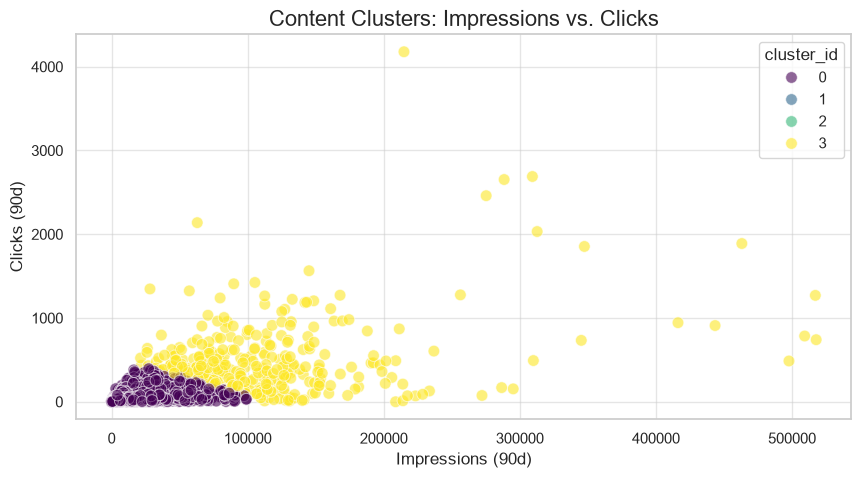

In [8]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x='impressions_90d',
    y='clicks_90d',
    hue='cluster_id',
    palette='viridis',
    alpha=0.6,
    s=70
)
plt.title('Content Clusters: Impressions vs. Clicks', fontsize=16)
plt.xlabel('Impressions (90d)', fontsize=12)
plt.ylabel('Clicks (90d)', fontsize=12)


## 3. Success metric
To evaluate the quality and business utility of the clusters, we will use a combination of mathematical and qualitative metrics:

* **Silhouette Score:** Measures how similar an item is to its own cluster compared to other clusters (aiming for values close to 1).
* **Davies-Bouldin Index:** Evaluates cluster separation and compactness (lower values indicate better clustering).
* **Cluster Business Interpretability (Domain Validation):** Qualitative check to ensure each generated cluster represents a clear, distinct content strategy or user intent group.

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
sil_score = silhouette_score(X_scaled , df['cluster_id'])
db_score = davies_bouldin_score(X_scaled,df['cluster_id'])

print(f"Silhouette Score:     {sil_score:.4f}  (Higher is better, range [-1, 1])")
print(f"Davies-Bouldin Index: {db_score:.4f}  (Lower is better, closer to 0)")

Silhouette Score:     0.8002  (Higher is better, range [-1, 1])
Davies-Bouldin Index: 0.7402  (Lower is better, closer to 0)


## 4. The unit of analysis, as a real dataframe

* **Granularity:** One row = One unique content piece (`content_id`).
* **Entity Representation:** Each observation represents an individual article/page with its accumulated performance, traffic metrics, and engagement signals (e.g., search volume, impressions, clicks, CTR, and scroll rates).

### Features & Proxy Target
* **Input Features ($X$):** High-dimensional metrics including `search_volume`, `impressions_90d`, `clicks_90d`, `ctr`, `engagement_rate`, `cpc`, and `word_count`.
* **Proxy Target ($y$):** An engineered `cluster_id` column generated via K-Means clustering to group articles into semantic and performance categories.

In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
print(f"Dataset Shape: {df.shape[0]} rows (content items), {df.shape[1]} columns\n")

display_cols = [
    'content_id',
    'cluster_id',
    'search_volume',
    'impressions_90d',
    'clicks_90d',
    'ctr',
    'engagement_rate',
    'word_count'
]

available_display_cols = [col for col in display_cols if col in df.columns]

print("--- Unit of Analysis Preview (1 Row = 1 Content Item) ---")
display(df[available_display_cols].tail(5))

Dataset Shape: 30000 rows (content items), 45 columns

--- Unit of Analysis Preview (1 Row = 1 Content Item) ---


,content_id,cluster_id,search_volume,impressions_90d,clicks_90d,ctr,engagement_rate,word_count
29995,content_c322796023c8,0,10.0,1,0,0.00,0.00,1386.0
29996,content_526572edb3fa,0,0.0,761,3,0.39,0.00,2654.0
29997,content_38112bdd0c6e,0,10.0,6336,12,0.19,0.00,2857.0
29998,content_ab26273a7e7a,3,10.0,154763,340,0.22,1.73,NaN
29999,content_887020f20b5e,0,0.0,4234,80,1.89,6.58,4124.0


### 5. Cluster Profiling & Interpretation

* **Cluster 0 — High Impressions / Low CTR (Opportunity Gap):**
  * **Characteristics:** High `word_count` (~3112), moderate `impressions_90d` (~3948), low `ctr` (0.31%).
  * **Action:** Rewrite titles and meta descriptions to turn high impressions into actual clicks.

* **Cluster 1 — Low Reach / High Engagement (Niche Content):**
  * **Characteristics:** Low `impressions_90d` (4.82), exceptionally high `ctr` (37.55%) and high `engagement_rate` (11.54).
  * **Action:** Expand keyword research and boost internal linking to scale up visibility/impressions for this highly engaging content.

* **Cluster 2 — Underperforming & Low Engagement Content:**
  * **Characteristics:** High `word_count` (~3456), moderate `impressions` (~3316), but very low `clicks_90d` (1.90) and lowest `engagement_rate` (1.11).
  * **Action:** Audit content quality; rewrite/update to improve user retention or consider consolidating with stronger pages.

* **Cluster 3 — Top Traffic Drivers / Core Powerhouse (High Impact):**
  * **Characteristics:** Highest `impressions_90d` (~117k), highest `clicks_90d` (~486), highest `word_count` (~3888).
  * **Action:** Maintain freshness and update data regularly to protect top search rankings and guard against competitors.

In [11]:
profile = df.groupby('cluster_id')[[
    'word_count', 'impressions_90d', 'clicks_90d', 'ctr', 'engagement_rate'
]].mean().round(2)

display(profile)

,word_count,impressions_90d,clicks_90d,ctr,engagement_rate
cluster_id,,,,,
0,3112.32,3948.21,10.80,0.31,2.48
1,1245.73,4.82,1.44,37.55,11.54
2,3456.91,3316.83,1.90,0.44,1.11
3,3888.62,117097.90,486.63,0.53,3.27


### Why Machine Learning (Clustering) Beats Traditional Rule-Based Approaches

In traditional web analytics and SEO, content optimization relies on hard-coded heuristics (e.g., *IF word_count > 2000 AND CTR < 1% THEN Flag for Title Optimization*). However, Machine Learning outperforms this rigid approach in key ways:

1. **Multi-Dimensional Complexity & Pattern Discovery:**
   * **Rule-based limit:** Humans can only write rules for 2 or 3 metrics at a time (e.g., Clicks vs. Impressions).
   * **ML Advantage:** Clustering seamlessly processes high-dimensional feature spaces simultaneously (`word_count`, `impressions`, `clicks`, `ctr`, `engagement_rate`, `cpc`), identifying non-linear patterns and hidden content segments that manual rules would miss.

2. **Adaptability to Dynamic SEO Distributions:**
   * **Rule-based limit:** Static thresholds (like `impressions > 5000`) break easily due to extreme skewness, seasonal traffic changes, or algorithm updates.
   * **ML Advantage:** Unsupervised clustering relies on relative mathematical distances (via normalized feature vectors) rather than arbitrary hardcoded numbers, automatically adjusting as traffic scales.

3. **Handling Non-Linear Relationships:**
   * **Rule-based limit:** Assumes linear or binary conditions (e.g., longer content always means higher engagement).
   * **ML Advantage:** As seen in our cluster analysis, Cluster 1 achieved the highest CTR (37.55%) despite having a lower average word count (1245 words), proving that metrics interact non-linearly. ML captures these subtle interactions effortlessly.

4. **Scalability & Automated Categorization:**
   * **Rule-based limit:** Writing, maintaining, and updating nested IF/ELSE statements for thousands of pages is error-prone and unscalable.
   * **ML Advantage:** A trained clustering algorithm automatically assigns any newly published content item (`content_id`) to its corresponding cluster in milliseconds.

#### Code Comparison: Rules vs. Machine Learning
## **1. Machine Learning Approach (Dynamic & Scalable):**

In [12]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster_id'] = kmeans.fit_predict(X_scaled)

## **2. Traditional Rule-Based Approach (Rigid & Hardcoded):**
```python
# Hardcoded rules fail on edge cases and complex metric interactions
def classify_content(row):
    if row['impressions_90d'] > 100000 and row['ctr'] < 0.01:
        return "Opportunity Gap"
    elif row['word_count'] > 3000 and row['engagement_rate'] > 5.0:
        return "Core Content"
    else:
        return "Unclassified"  # Rigid, leaves many edge cases out


## Self-check

Before you submit, confirm each line honestly:

- [✅] Every section above is filled — markdown thinking AND the code that backs it
- [✅] The notebook runs top to bottom with no errors (Runtime → Run all)
- [✅] No client names, URLs, or private queries anywhere
- [✅] My claims use careful words: observed, measured, directional, decision-support
- [✅] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.